# Poster-based movie genre classification

Multi-label classification of 13 genres from a **movie poster** on the MovieScope dataset. This is the image part of the project. Plot text lives in `01_text_classification.ipynb`, and combining the two modalities lives in `03_fusion.ipynb`.

The starting point is [Multi-label Movie Genre Classification Using Multiple Modalities](http://cs230.stanford.edu/projects_fall_2021/reports/102983714.pdf) (LeBaron, Stanford CS230). Their poster model is VGG-16 with frozen convolutional layers and scores **0.446 macro AP**. We first try to match that number, then see how much we gain by changing only the backbone.

| Experiment | Backbone | What it tests |
|---|---|---|
| E1 | VGG-16 (paper setup) | Can we reproduce the published poster result |
| E2 | VGG-16 plus regularization | Is the bottleneck overfitting (dropout, augmentations, weight decay) |
| E3 | CLIP ViT-B/32 | Is the bottleneck the representation (frozen vision language encoder plus a linear head) |

The order is deliberate. Each experiment answers the question the previous one left open.

## 1. Setup

We import `helpers`, the shared module used by the text pipeline, so splits, genre names, and metric functions stay **identical**. If each pipeline loaded data its own way, poster vs text comparison would not be valid, and later fusion could not align rows by `movie_id`.

Training does not run in this notebook. Scripts under `scripts/` already wrote `history.json` and `test_metrics_*.json`. We only read those files, so the notebook opens without a GPU and the numbers match what is on disk.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT))

from helpers import GENRES, PAPER_RESULTS, load_split
from poster.config import ROOT as POSTER_ROOT

RESULTS = ROOT / "results" / "poster"
MODELS = ROOT / "models" / "poster"
FUSION_RESULTS = ROOT / "results" / "fusion"

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")
plt.rcParams.update({"figure.figsize": (10, 5), "font.size": 11})

## 2. Data

Same train / val / test split as the text pipeline (3454 / 491 / 989). Each movie has one JPG poster and one or more genres.

The two plots below show why the task is hard:

- **Class imbalance.** `drama` has 1806 training examples, `animation` only 175. A model that always predicts a few frequent genres looks good on accuracy and is useless.
- **Multi-label density.** Most movies have two or three genres, so the label matrix is sparse (about 80% zeros). We do not report accuracy. We report Average Precision, as in the paper: AP looks at ranking of probabilities and does not reward predicting zeros.

train  3454   val   491   test   989


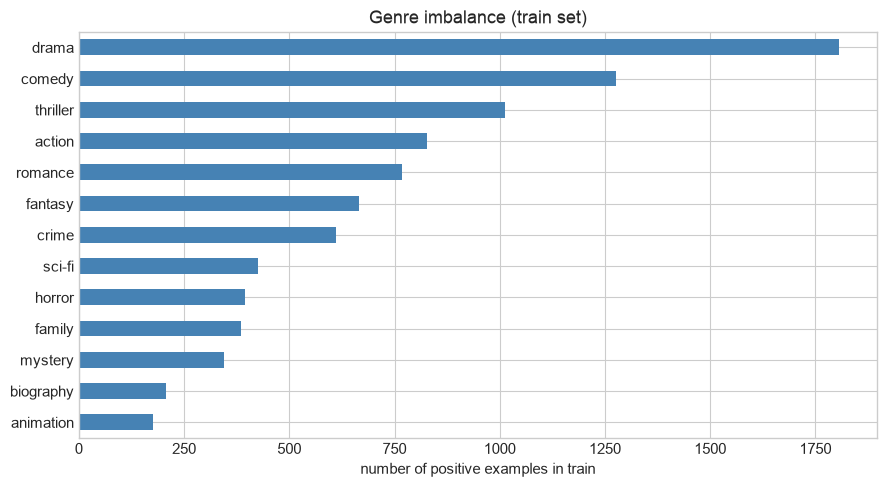

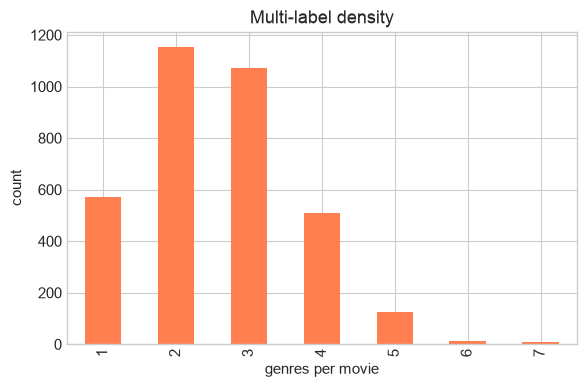

In [2]:
train = load_split("train")
val = load_split("val")
test = load_split("test")

print(f"train {len(train):5d}   val {len(val):5d}   test {len(test):5d}")

counts = train[GENRES].sum().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 5))
counts.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("number of positive examples in train")
ax.set_title("Genre imbalance (train set)")
plt.tight_layout()
plt.show()

labels_per_movie = train[GENRES].sum(axis=1)
fig, ax = plt.subplots(figsize=(6, 4))
labels_per_movie.value_counts().sort_index().plot(kind="bar", ax=ax, color="coral")
ax.set_xlabel("genres per movie")
ax.set_ylabel("count")
ax.set_title("Multi-label density")
plt.tight_layout()
plt.show()

We use **weighted BCE**. For each genre, `pos_weight` is the ratio of negatives to positives in train, as in the paper. The plot below shows how spread out those weights are: `drama` is 0.91, `animation` is 18.74.

Missing an animation example is penalized about twenty times more than missing a drama example. Without that, the model quickly learns to output near-zero probability on rare genres, a local minimum it does not leave. Weights are computed **only on train** and saved in `results/poster/class_weights.json`, so all three experiments use the same values.

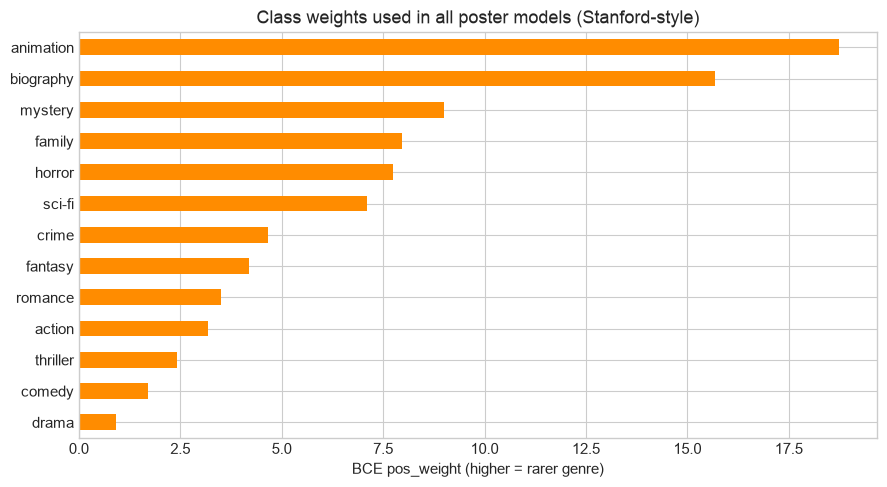

In [3]:
weights = json.loads((RESULTS / "class_weights.json").read_text())
w = pd.Series(weights).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
w.plot(kind="barh", ax=ax, color="darkorange")
ax.set_xlabel("BCE pos_weight (higher = rarer genre)")
ax.set_title("Class weights used in all poster models (Stanford-style)")
plt.tight_layout()
plt.show()

A few random training posters with their genres. Worth looking at before the numbers: animation and horror have a visual language (palette, type, composition). For `biography` or `mystery`, even a person often could not guess from the image alone.

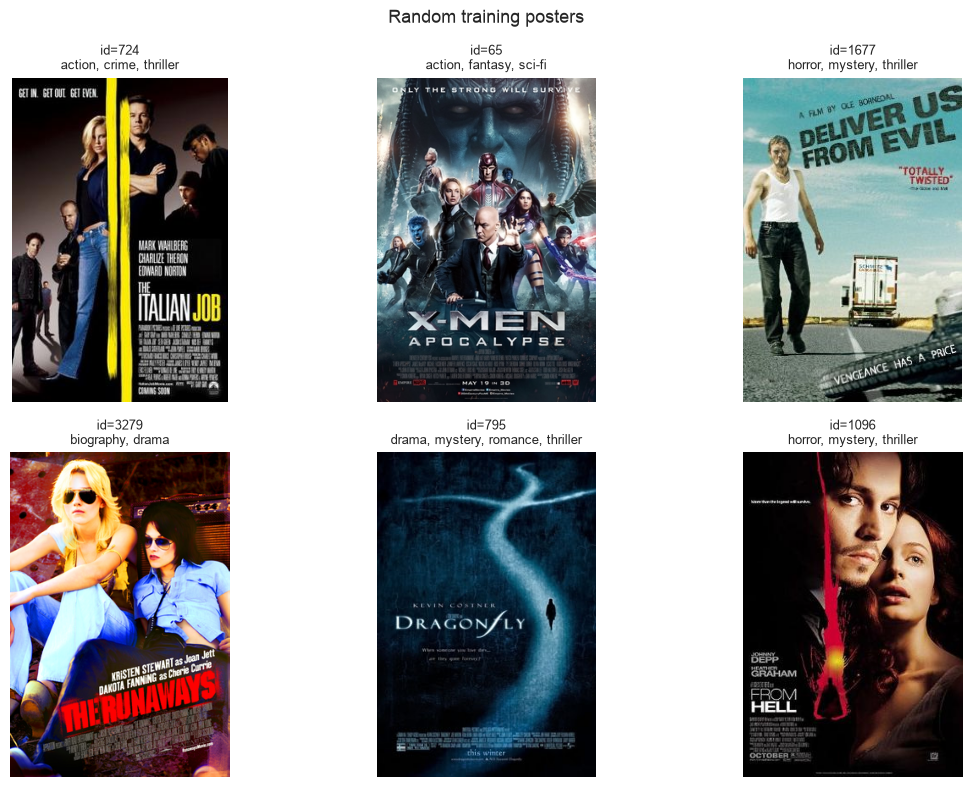

In [4]:
sample_ids = train.sample(6, random_state=42)["movie_id"].tolist()
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, mid in zip(axes.ravel(), sample_ids):
    row = train[train["movie_id"] == mid].iloc[0]
    img = Image.open(ROOT / "train_data" / "images" / f"{mid}.jpg")
    ax.imshow(img)
    ax.axis("off")
    genres = ", ".join(g for g in GENRES if row[g] == 1)
    ax.set_title(f"id={mid}\n{genres}", fontsize=9)
plt.suptitle("Random training posters", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Training protocol

All three experiments share the same frame. Only the thing each experiment tests changes.

| Setting | Our pipeline | Paper (poster) |
|---|---|---|
| Loss | Weighted BCE (`pos_weight` from train counts) | same |
| Optimizer | Adam, lr 1e-3 | Adam |
| Batch | 32 (16 for CLIP) | not reported |
| Early stopping | **val macro AP**, patience 10 (E1) / 5 (E2, E3) | val **loss**, about 20 epochs |
| Metric | Average Precision, macro as primary | same |
| E1 backbone | VGG-16 ImageNet, frozen conv layers | same |
| Seed | 42 | not reported |

Two choices need a reason.

**Why early stop on val macro AP, not val loss.** The paper stops on validation loss. Here val loss and val macro AP do not move together: because of class weights, val loss can keep dropping while ranking of rare genres already gets worse. We report macro AP, so we pick the checkpoint by that same metric. That is a deliberate departure from the paper and we say so.

**Why macro AP as the main metric.** Micro and sample AP are dominated by frequent genres, so a model that only does well on `drama` and `comedy` looks fine there. Macro treats all 13 genres equally and most strictly penalizes ignoring rare classes, which is what we care about. The paper reports all three, so we do too.

## 4. Three experiments

Once E1 matches the paper, the remaining question is **why the poster model is this weak**. 0.45 macro AP is low. The paper notes that the poster model converged much faster than the others and then overfit. That suggests two hypotheses:

1. **Overfitting.** A 4096 to 1000 to 13 head has too many parameters for 3454 images. Check: dropout 0.5, weight decay 1e-4, and augmentations (horizontal flip, random crop, mild color jitter). That is E2.
2. **Representation.** VGG-16 was trained to classify ImageNet objects. Poster genre is not an object; it is mood, type, and palette. CLIP was trained on image/text pairs, so its features carry semantics like "horror poster" or "animated film". Check: frozen CLIP encoder plus one linear head (linear probe). That is E3.

For a fair comparison we change **only** what the hypothesis tests. Split, loss, class weights, metric, seed, and the early stopping rule stay the same.

The table below is loaded from saved files, not typed by hand.

In [5]:
EXPERIMENTS = {
    "E1 VGG Stanford": {
        "backbone": "vgg16_stanford",
        "history": MODELS / "vgg16_stanford_p10" / "history.json",
        "metrics": RESULTS / "test_metrics_vgg16_stanford.json",
        "label": "VGG-16 Stanford",
    },
    "E2 VGG regularized": {
        "backbone": "vgg16_regularized",
        "history": MODELS / "vgg16_regularized" / "history.json",
        "metrics": RESULTS / "test_metrics_vgg16_regularized.json",
        "label": "VGG-16 regularized",
    },
    "E3 CLIP ViT-B/32": {
        "backbone": "clip_vit_b32",
        "history": MODELS / "clip_vit_b32" / "history.json",
        "metrics": RESULTS / "test_metrics_clip_vit_b32.json",
        "label": "CLIP ViT-B/32",
    },
}

def load_history(path: Path) -> pd.DataFrame:
    data = json.loads(path.read_text())
    return pd.DataFrame(data["epochs"])

def load_test_metrics(path: Path) -> dict:
    return json.loads(path.read_text())

summary_rows = []
histories = {}
per_genre = {}

for name, cfg in EXPERIMENTS.items():
    if not cfg["history"].exists() or not cfg["metrics"].exists():
        print(f"skip {name}: missing files")
        continue
    hist = load_history(cfg["history"])
    meta = json.loads(cfg["history"].read_text())
    met = load_test_metrics(cfg["metrics"])
    histories[name] = hist
    per_genre[name] = pd.Series(met["per_genre_ap"], name="AP")
    summary_rows.append({
        "experiment": name,
        "backbone": cfg["backbone"],
        "best_epoch": meta["best_epoch"],
        "val_macro_ap": meta["best_val_macro_ap"],
        "test_macro_ap": met["macro_ap"],
        "test_micro_ap": met["micro_ap"],
        "test_sample_ap": met["sample_ap"],
        "epochs_run": len(hist),
    })

summary = pd.DataFrame(summary_rows).set_index("experiment")
display(summary.round(4))

,backbone,best_epoch,val_macro_ap,test_macro_ap,test_micro_ap,test_sample_ap,epochs_run
experiment,,,,,,,
E1 VGG Stanford,vgg16_stanford,11,0.4479,0.4545,0.4776,0.6000,21
E2 VGG regularized,vgg16_regularized,5,0.4287,0.4550,0.4288,0.5629,15
E3 CLIP ViT-B/32,clip_vit_b32,1,0.6021,0.6175,0.6219,0.7416,11


## 5. Training curves

Left: val macro AP by epoch (checkpoint criterion). Right: loss, solid train, dashed val.

The right plot matches the paper: **the train vs val loss gap opens very early**. On both VGG models train loss keeps dropping while val stops improving after a few epochs. E2 has a smaller gap, so regularization is doing its job, but val macro AP is not better. That already answers the first hypothesis.

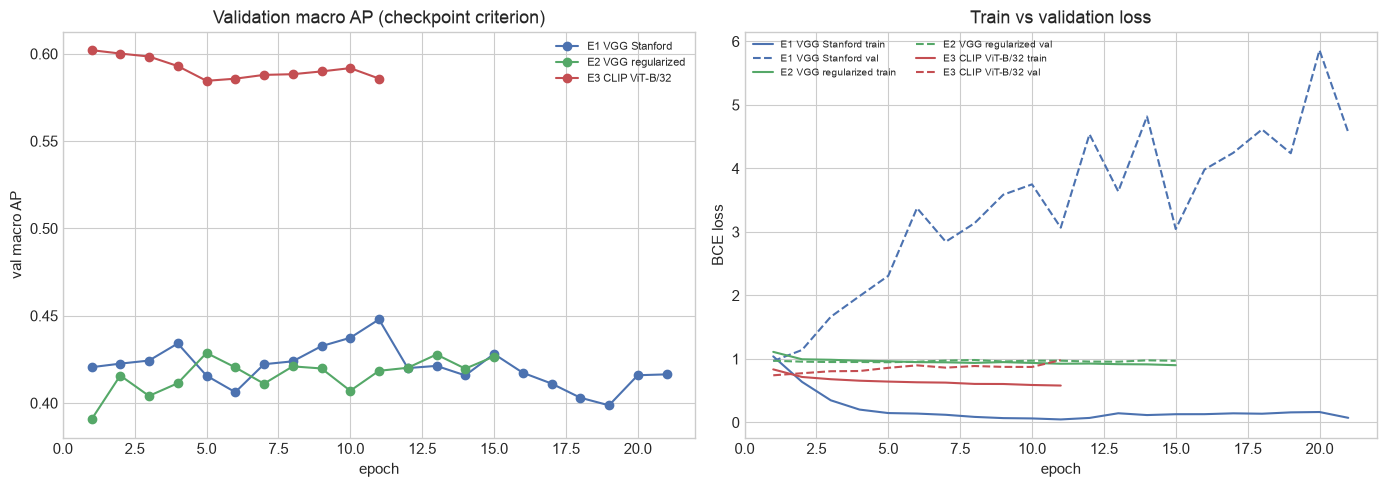

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"E1 VGG Stanford": "#4C72B0", "E2 VGG regularized": "#55A868", "E3 CLIP ViT-B/32": "#C44E52"}

for name, hist in histories.items():
    c = colors.get(name, "gray")
    axes[0].plot(hist["epoch"], hist["val_macro_ap"], marker="o", label=name, color=c)
    axes[1].plot(hist["epoch"], hist["train_loss"], label=f"{name} train", color=c, linestyle="-")
    axes[1].plot(hist["epoch"], hist["val_loss"], label=f"{name} val", color=c, linestyle="--")

axes[0].set_xlabel("epoch")
axes[0].set_ylabel("val macro AP")
axes[0].set_title("Validation macro AP (checkpoint criterion)")
axes[0].legend(fontsize=8)

axes[1].set_xlabel("epoch")
axes[1].set_ylabel("BCE loss")
axes[1].set_title("Train vs validation loss")
axes[1].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

### Why the best CLIP checkpoint is epoch 1

The CLIP encoder is frozen. Only the linear head trains (512 to 13). On 3454 examples that head converges after one pass: val macro AP is 0.6021 in epoch 1, then falls while train loss still drops. That is not a bug in early stopping. The head overfits, and the rule correctly keeps epoch 1.

It is reproducible: with seed 42, two runs pick the same best checkpoint. E3 is also the cheapest of the three experiments, because quality shows up almost immediately.

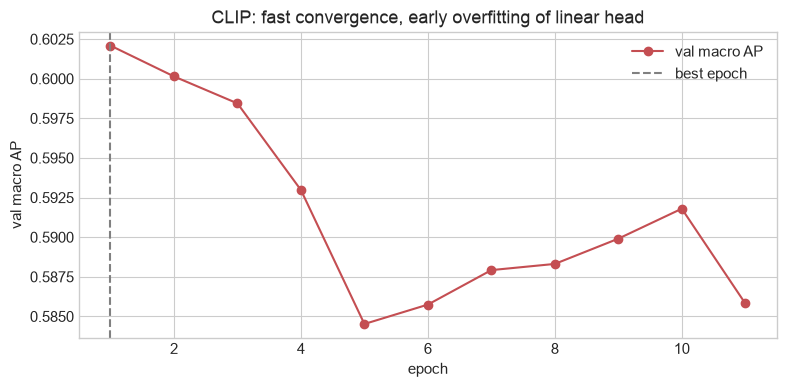

In [7]:
if "E3 CLIP ViT-B/32" in histories:
    h = histories["E3 CLIP ViT-B/32"]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(h["epoch"], h["val_macro_ap"], "o-", color="#C44E52", label="val macro AP")
    ax.axvline(1, color="gray", linestyle="--", label="best epoch")
    ax.set_xlabel("epoch")
    ax.set_ylabel("val macro AP")
    ax.set_title("CLIP: fast convergence, early overfitting of linear head")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 6. Test results

The test set (989 movies) is looked at once, at the end, per experiment. All model choices were made on validation.

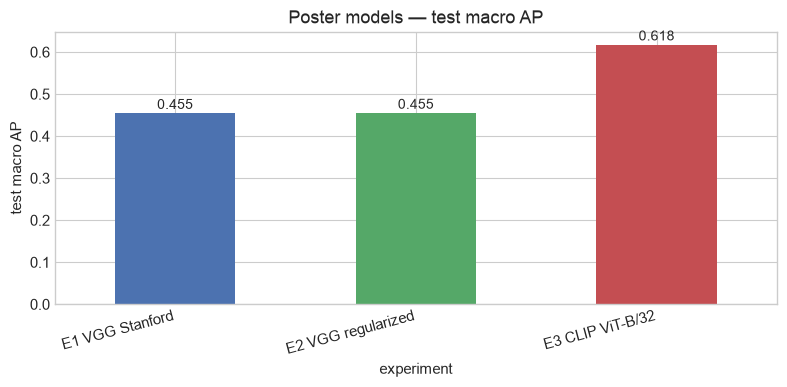

In [8]:
if not summary.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    summary["test_macro_ap"].plot(kind="bar", ax=ax, color=[colors.get(i, "gray") for i in summary.index])
    ax.set_ylabel("test macro AP")
    ax.set_title("Poster models, test macro AP")
    ax.set_xticklabels(summary.index, rotation=15, ha="right")
    for i, v in enumerate(summary["test_macro_ap"]):
        ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=10)
    plt.tight_layout()
    plt.show()

Macro AP averages over genres, so it hides where the model works. Below we break AP down by genre.

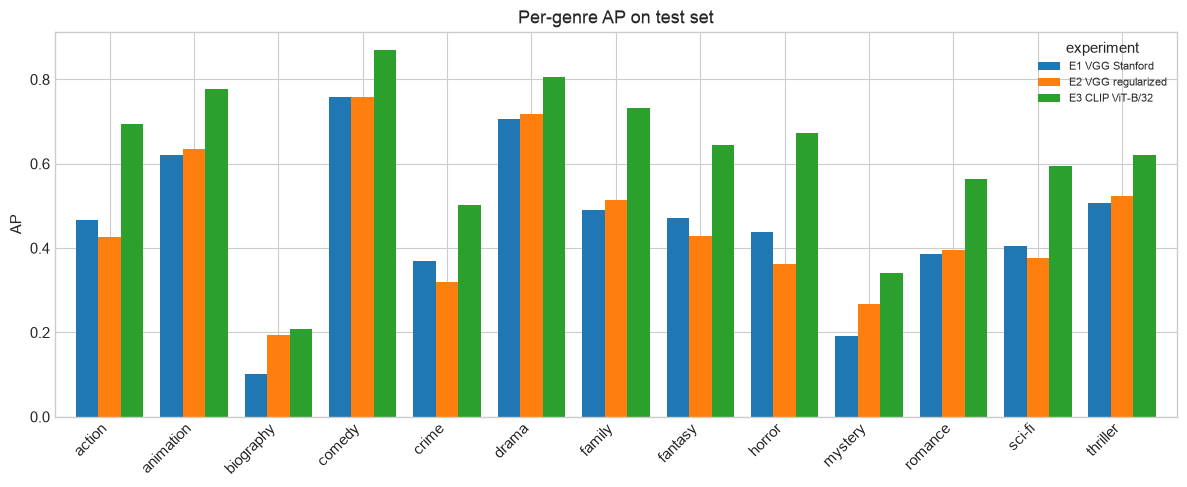

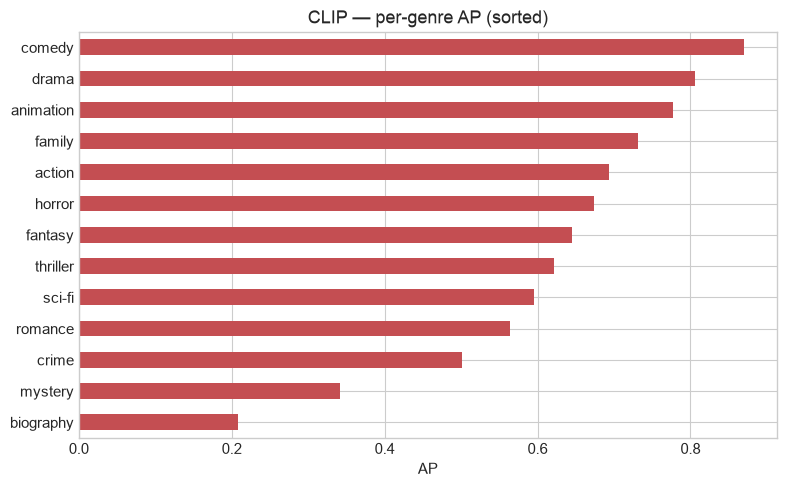

In [9]:
if per_genre:
    ap_df = pd.DataFrame(per_genre).sort_index()
    fig, ax = plt.subplots(figsize=(12, 5))
    ap_df.plot(kind="bar", ax=ax, width=0.8)
    ax.set_ylabel("AP")
    ax.set_title("Per-genre AP on test set")
    ax.legend(title="experiment", fontsize=8)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    if "E3 CLIP ViT-B/32" in per_genre:
        clip_ap = per_genre["E3 CLIP ViT-B/32"].sort_values()
        fig, ax = plt.subplots(figsize=(8, 5))
        clip_ap.plot(kind="barh", ax=ax, color="#C44E52")
        ax.set_xlabel("AP")
        ax.set_title("CLIP, per-genre AP (sorted)")
        plt.tight_layout()
        plt.show()

The per-genre breakdown is the most informative part. For CLIP:

| Strongest | AP | Weakest | AP |
|---|---|---|---|
| comedy | 0.870 | biography | 0.209 |
| drama | 0.805 | mystery | 0.341 |
| animation | 0.777 | crime | 0.501 |
| family | 0.732 | romance | 0.564 |

The pattern is clear. The model is good where a genre has a **visual signature**, and weak where the genre is defined by story structure. `animation` has AP 0.777 with only 175 training examples, because drawing style is unambiguous. `biography` has 207 examples and AP 0.209, because a biography poster looks like a drama poster. That is missing signal in the image, not missing data.

The same genres (`biography`, `mystery`) are also weakest in the text model (`03_fusion.ipynb`). Those labels are hard in general, not only for images, likely also because annotation in the dataset is inconsistent.

## 7. Comparison with the paper

Direct comparison on the **poster modality**, which is the fairest one: same dataset, same metric, same kind of model.

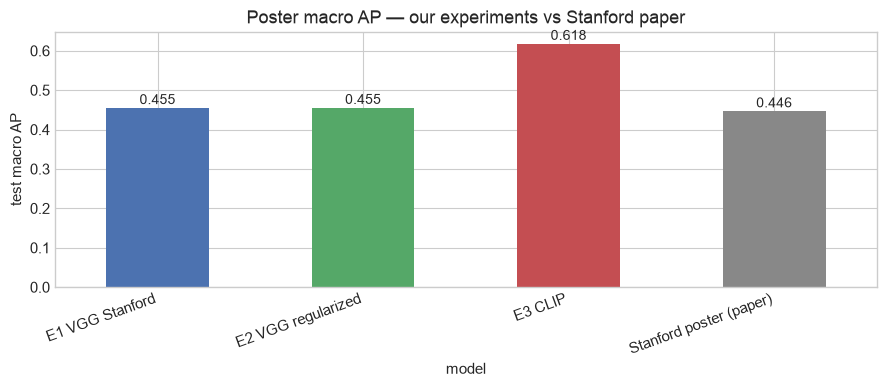

,AP_macro
model,
E1 VGG Stanford,0.4545
E2 VGG regularized,0.4550
E3 CLIP,0.6175
Stanford poster (paper),0.4463


In [10]:
our_poster = pd.DataFrame({
    "model": ["E1 VGG Stanford", "E2 VGG regularized", "E3 CLIP"],
    "AP_macro": [
        summary.loc["E1 VGG Stanford", "test_macro_ap"] if "E1 VGG Stanford" in summary.index else np.nan,
        summary.loc["E2 VGG regularized", "test_macro_ap"] if "E2 VGG regularized" in summary.index else np.nan,
        summary.loc["E3 CLIP ViT-B/32", "test_macro_ap"] if "E3 CLIP ViT-B/32" in summary.index else np.nan,
    ],
}).set_index("model")

paper_poster = PAPER_RESULTS.loc[["Poster (rad)"]].rename(index={"Poster (rad)": "Stanford poster (paper)"})

compare_poster = pd.concat([
    our_poster[["AP_macro"]],
    paper_poster[["AP_macro"]],
])

fig, ax = plt.subplots(figsize=(9, 4))
bars = compare_poster["AP_macro"].plot(kind="bar", ax=ax, color=["#4C72B0", "#55A868", "#C44E52", "#888888"])
ax.set_ylabel("test macro AP")
ax.set_title("Poster macro AP: our experiments vs Stanford paper")
ax.set_xticklabels(compare_poster.index, rotation=20, ha="right")
for i, v in enumerate(compare_poster["AP_macro"]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

display(compare_poster.round(4))

Three takeaways:

- **E1 is 0.4545 vs 0.446 in the paper.** The gap is 0.008, within run to run noise. Replication worked and the pipeline is sound.
- **E2 is 0.4550, essentially E1.** Regularization did not help, so the first hypothesis fails: a weak poster model is not (only) overfitting. Negative result, but useful, because it is what motivated E3.
- **E3 is 0.6175, +0.17 over the paper.** Changing the backbone did more than any regularization setting, which supports the second hypothesis.

The plot below puts our best poster model next to all paper modalities. Our poster model (0.6175) beats their video model (0.574) and their four-modality combination (0.564), and roughly matches their best single modality, text (0.620). That is not a better head architecture. It is a better pretrained representation: CLIP in this form was not available when the paper poster model was built on ImageNet VGG.

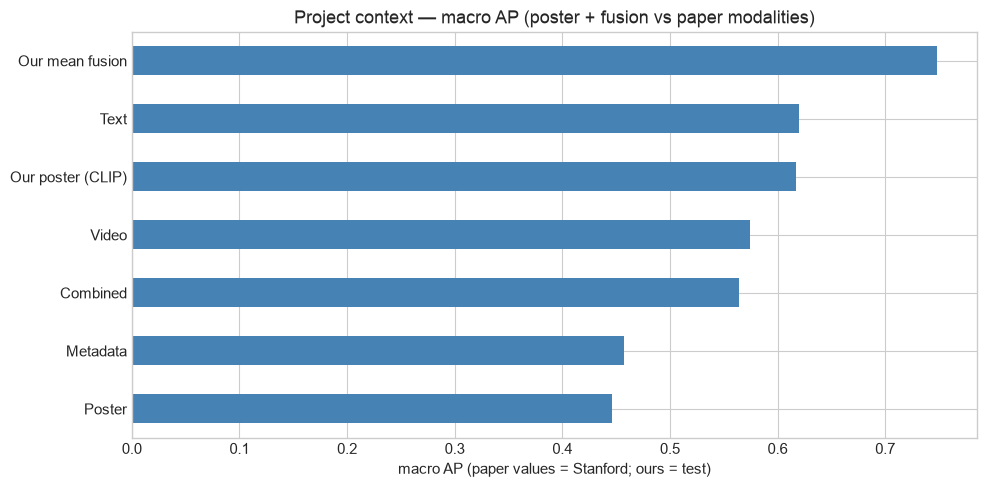

,AP_micro,AP_macro,AP_samples
Poster,0.5201,0.4463,0.6572
Metadata,0.4944,0.4574,0.6284
Video,0.5899,0.5739,0.6964
Text,0.6317,0.6195,0.7497
Combined,0.6270,0.5641,0.7358
Our poster (CLIP),0.6219,0.6175,0.7416
Our mean fusion,0.7915,0.7479,0.8618


In [11]:
context = PAPER_RESULTS.copy()
context.index = [x.replace(" (rad)", "") for x in context.index]

if "E3 CLIP ViT-B/32" in summary.index:
    context.loc["Our poster (CLIP)"] = [
        summary.loc["E3 CLIP ViT-B/32", "test_micro_ap"],
        summary.loc["E3 CLIP ViT-B/32", "test_macro_ap"],
        summary.loc["E3 CLIP ViT-B/32", "test_sample_ap"],
    ]

fusion_csv = FUSION_RESULTS / "comparison_test.csv"
if fusion_csv.exists():
    fusion = pd.read_csv(fusion_csv, index_col=0)
    if "Mean fusion (poster + text)" in fusion.index:
        row = fusion.loc["Mean fusion (poster + text)"]
        context.loc["Our mean fusion"] = [row["AP_micro"], row["AP_macro"], row["AP_samples"]]

fig, ax = plt.subplots(figsize=(10, 5))
context["AP_macro"].sort_values(ascending=True).plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("macro AP (paper values = Stanford; ours = test)")
ax.set_title("Project context, macro AP (poster + fusion vs paper modalities)")
plt.tight_layout()
plt.show()

display(context.round(4))

## 8. Conclusions

1. **E1 reproduces the paper:** 0.4545 test macro AP vs published 0.446. Data, loss, and metric are therefore checked.
2. **E2 shows regularization is not the fix.** Dropout, weight decay, and augmentations shrink the train/val gap, but val macro AP stays 0.4550. The limit is not head capacity.
3. **E3 is the clear winner:** 0.6175 macro AP with a frozen CLIP encoder and one linear head, from epoch 1. The limit was the representation.
4. **By genre**, the model works where there is a visual signature (`comedy`, `drama`, `animation`, `family`) and fails on `biography` and `mystery`. More poster tuning will not fix that. We need another modality.
5. That leads to `03_fusion.ipynb`, where the poster is combined with the text model and reaches **0.7479 macro AP**.

### Limitations

- We did not train video or metadata models, so comparison with the paper "Combined" result is context, not a one to one match.
- The CLIP checkpoint is 605 MB, so it is not in the repo. Reproduce it with the commands below.
- We trained only a linear head on frozen CLIP. The CLIP encoder itself was not fine-tuned.

### Reproduction

```bash
python scripts/train_poster.py --backbone vgg16_stanford --device mps --patience 10
python scripts/train_poster.py --backbone vgg16_regularized --device mps
python scripts/train_poster.py --backbone clip_vit_b32 --device mps --batch-size 16
python scripts/evaluate.py --backbone clip_vit_b32 --device mps --batch-size 16
```